In [ ]:
!pip install pandas numpy matplotlib scikit-learn joblib

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
df=pd.read_csv(r"/content/late_to_office_dataset.csv")

In [ ]:
df

,distance_km,time_left_minutes,will_be_late
0,11.86,20.74,1
1,28.57,51.06,1
2,22.23,79.20,0
3,18.36,67.24,0
4,5.52,73.56,0
...,...,...,...
995,3.66,60.84,0
996,27.60,86.31,1
997,4.97,10.86,1
998,28.56,9.85,1


In [ ]:
print(df.head())

   distance_km  time_left_minutes  will_be_late
0        11.86              20.74             1
1        28.57              51.06             1
2        22.23              79.20             0
3        18.36              67.24             0
4         5.52              73.56             0


In [ ]:
print(df.shape)

(1000, 3)


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   distance_km        1000 non-null   float64
 1   time_left_minutes  1000 non-null   float64
 2   will_be_late       1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB
None


In [ ]:
print(df.describe())

       distance_km  time_left_minutes  will_be_late
count  1000.000000         1000.00000   1000.000000
mean     15.217590           48.09644      0.481000
std       8.472039           24.83613      0.499889
min       1.130000            5.27000      0.000000
25%       7.842500           25.49000      0.000000
50%      15.405000           49.09000      0.000000
75%      22.582500           69.63500      1.000000
max      29.990000           89.95000      1.000000


In [ ]:
print(df.isnull().sum())

distance_km          0
time_left_minutes    0
will_be_late         0
dtype: int64


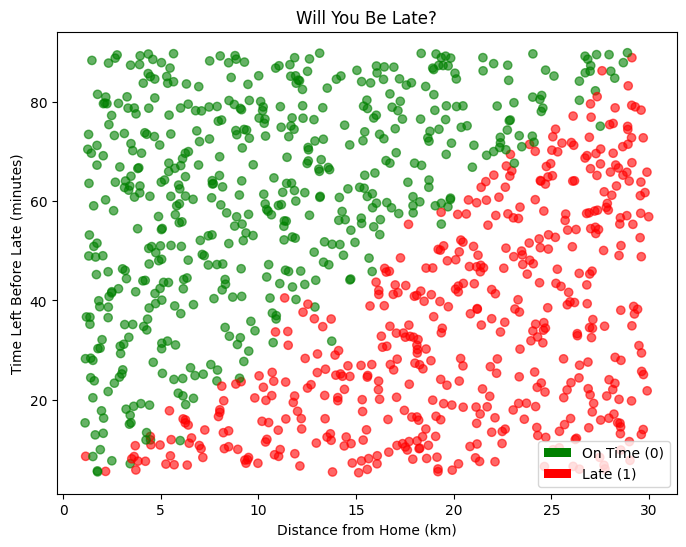

In [ ]:
plt.figure(figsize=(8, 6))

colors = df["will_be_late"].map({0: "green", 1: "red"})

plt.scatter(
    df["distance_km"],
    df["time_left_minutes"],
    c=colors,
    alpha=0.6
)

plt.xlabel("Distance from Home (km)")
plt.ylabel("Time Left Before Late (minutes)")
plt.title("Will You Be Late?")

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', label='On Time (0)'),
    Patch(facecolor='red', label='Late (1)')
]
plt.legend(handles=legend_elements)

plt.show()

In [ ]:
#x is input
X=df[["distance_km","time_left_minutes"]]
#y is output
Y=df["will_be_late"]

In [ ]:
X

,distance_km,time_left_minutes
0,11.86,20.74
1,28.57,51.06
2,22.23,79.20
3,18.36,67.24
4,5.52,73.56
...,...,...
995,3.66,60.84
996,27.60,86.31
997,4.97,10.86
998,28.56,9.85


In [ ]:
Y

,will_be_late
0,1
1,1
2,0
3,0
4,0
...,...
995,0
996,1
997,1
998,1


In [ ]:
from sklearn.model_selection import train_test_split


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.3) #300 rows for testing

In [ ]:
X_train

,distance_km,time_left_minutes
51,23.48,49.96
893,12.52,22.34
908,8.52,32.79
363,16.82,58.68
228,26.87,88.64
...,...,...
679,26.10,64.07
314,25.24,43.45
70,23.40,30.19
617,9.03,61.26


In [ ]:
y_train

,will_be_late
51,1
893,1
908,0
363,0
228,0
...,...
679,1
314,1
70,1
617,0


In [ ]:
X_test.shape

(300, 2)

In [ ]:
X_test

,distance_km,time_left_minutes
139,29.18,55.35
76,23.37,37.67
712,14.68,71.36
475,29.80,61.75
835,13.15,60.80
...,...,...
344,12.56,68.13
208,1.15,28.26
665,5.43,77.37
250,9.54,72.71


In [ ]:
y_test

,will_be_late
581,1
230,0
931,1
554,1
134,1
...,...
395,1
617,0
463,0
602,0


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler=StandardScaler()

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled

array([[ 0.9630897 ,  0.07347602],
       [-0.33311792, -1.04572972],
       [-0.8061864 , -0.62227932],
       ...,
       [ 0.95362833, -0.7276354 ],
       [-0.74587017,  0.53136976],
       [ 1.02813661,  1.01236079]])

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lr=LogisticRegression()

In [ ]:
lr.fit(X_train_scaled,y_train)

LogisticRegression()

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt=DecisionTreeClassifier()

In [ ]:
dt.fit(X_train_scaled,y_train)

DecisionTreeClassifier()

In [ ]:
#Logistic Regression Evaluation
lr_predictions=lr.predict(X_test_scaled)


In [ ]:
lr_predictions

array([1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1])

In [ ]:
from sklearn.metrics import accuracy_score

print("The accuracy of lr is ",accuracy_score(lr_predictions,y_test))

The accuracy of lr is  0.9733333333333334


In [ ]:
#Decision Tree Evaluation
dt_predictions=dt.predict(X_test_scaled)

In [ ]:
dt_predictions

array([1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1])

In [ ]:
print("The accuracy of dt is ",accuracy_score(dt_predictions,y_test))

The accuracy of dt is  0.9533333333333334


In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
#Lr confusion matrix
confusion_matrix(lr_predictions,y_test)

array([[149,   4],
       [  4, 143]])

In [ ]:
#dt confusion matrix
confusion_matrix(dt_predictions,y_test)

array([[146,   7],
       [  7, 140]])

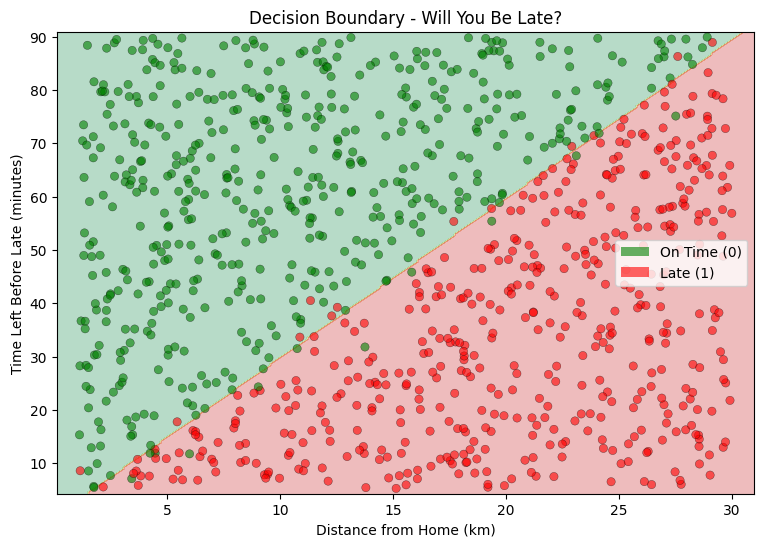

In [ ]:
# Create a mesh grid over the feature space
x_min, x_max = df["distance_km"].min() - 1, df["distance_km"].max() + 1
y_min, y_max = df["time_left_minutes"].min() - 1, df["time_left_minutes"].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = pd.DataFrame({"distance_km": xx.ravel(), "time_left_minutes": yy.ravel()})
grid_scaled = scaler.transform(grid)
Z = model.predict(grid_scaled).reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="RdYlGn_r")

colors = df["will_be_late"].map({0: "green", 1: "red"})
plt.scatter(df["distance_km"], df["time_left_minutes"], c=colors, alpha=0.6, edgecolors='k', linewidths=0.3)

plt.xlabel("Distance from Home (km)")
plt.ylabel("Time Left Before Late (minutes)")
plt.title("Decision Boundary - Will You Be Late?")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', alpha=0.6, label='On Time (0)'),
    Patch(facecolor='red', alpha=0.6, label='Late (1)')
]
plt.legend(handles=legend_elements)

plt.savefig("decision_boundary.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import joblib

In [ ]:
joblib.dump(lr, "late_to_office_model.pkl")


['late_to_office_model.pkl']

In [ ]:
# Example:
# 15 km away, only 20 minutes left before late

sample = pd.DataFrame({
    "distance_km": [15],
    "time_left_minutes": [20]
})

sample_scaled = scaler.transform(sample)

prediction = model.predict(sample_scaled)
probability = model.predict_proba(sample_scaled)

print("Prediction:", "Late" if prediction[0] == 1 else "On Time")
print("Probability - On Time: {:.2f}, Late: {:.2f}".format(probability[0][0], probability[0][1]))

Prediction: Late
Probability - On Time: 0.01, Late: 0.99
